# Filtros y transformada de Fourier #
## Índice<a id="0-índice"></a>
1. [Introducción a los Filtros en Sismología](#1-filtros)
2. [Transformada de Fourier y Series de Fourier](#2-fourier)
3. [Ejercicios](#4-ejercicios)


## 1. Introducción a los Filtros en Sismología <a id="1-filtros"></a>
**¿Qué es un filtro?**
Un filtro es un dispositivo (en el mundo físico) o un algoritmo (en el mundo matemático) que actúa sobre una señal de entrada para producir una señal de salida, posiblemente modificada. En sismología, los filtros se utilizan para:

- Corregir la respuesta del instrumento.

- Evitar efectos de aliasing.

- Separar frecuencias "deseadas" de las "no deseadas".

- Identificar señales armónicas.

- Modelar instrumentos de grabación específicos.

**Tipos de Filtros**
- Filtros lineales vs. no lineales: En sismología, se evitan los filtros no lineales porque introducen frecuencias no presentes en la señal original.

- Filtros analógicos vs. digitales: Los filtros analógicos pueden ser continuos o discretos, mientras que los digitales son siempre discretos.

- Filtros IIR (respuesta al impulso infinita) y FIR (respuesta al impulso finita): Los IIR son recursivos y causales, mientras que los FIR pueden ser causales o no causales.

**Respuesta en Frecuencia**

La respuesta en frecuencia de un filtro se define como la transformada de Fourier de la señal de salida dividida por la transformada de Fourier de la señal de entrada:
$$
T(jω)=\frac{Y(jω)}{X(jω)}
$$
Donde:
- $Y(jω)$: Transformada de Fourier de la señal de salida.
- $X(jω)$: Transformada de Fourier de la señal de entrada.

Para un filtro paso bajo, la respuesta en frecuencia es:
$$
|T(j\omega)| = \frac{1}{\sqrt{1 + \left(\frac{\omega}{\omega_c}\right)^{2n}}}
$$
Donde:
- $ω$: Frecuencia angular.
- $ω_c$: Frecuencia de corte.
- $n$: Orden del filtro.

In [2]:
import obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.signal as signal
from scipy.fft import fft, fftfreq

In [13]:
# Descargar datos del terremoto de Maule, Chile

client = Client("IRIS")

# Definir tiempo del evento
t1 = UTCDateTime("2010-02-27T06:34:14.000Z")
t2 = t1 + 60*60  # 1 hora de datos

# Descargar la traza
st = client.get_waveforms(network="CI", station="PASC", location="*", channel="BHZ",
                          starttime=t1, endtime=t2)

# Descargar inventario de respuesta
inv = client.get_stations(network="CI", station="PASC", location="*", channel="BHZ",
                          starttime=t1, endtime=t2, level="response")

In [14]:
# Corregir respuesta del instrumento usando inventario
st.remove_response(inventory=inv, output="VEL")

# Detrend y eliminar media
st.detrend("linear")
st.detrend("demean")

2 Trace(s) in Stream:
CI.PASC.00.BHZ | 2010-02-27T06:34:14.019500Z - 2010-02-27T07:34:13.994500Z | 40.0 Hz, 144000 samples
CI.PASC.10.BHZ | 2010-02-27T06:34:14.019500Z - 2010-02-27T07:34:13.994500Z | 40.0 Hz, 144000 samples

In [15]:
# Aplicar filtros
st_lp = st.copy()  # Filtro paso bajo
st_lp.filter('lowpass', freq=0.04, corners=4, zerophase=True)

st_hp = st.copy()  # Filtro paso alto
st_hp.filter('highpass', freq=0.04, corners=4, zerophase=True)

2 Trace(s) in Stream:
CI.PASC.00.BHZ | 2010-02-27T06:34:14.019500Z - 2010-02-27T07:34:13.994500Z | 40.0 Hz, 144000 samples
CI.PASC.10.BHZ | 2010-02-27T06:34:14.019500Z - 2010-02-27T07:34:13.994500Z | 40.0 Hz, 144000 samples

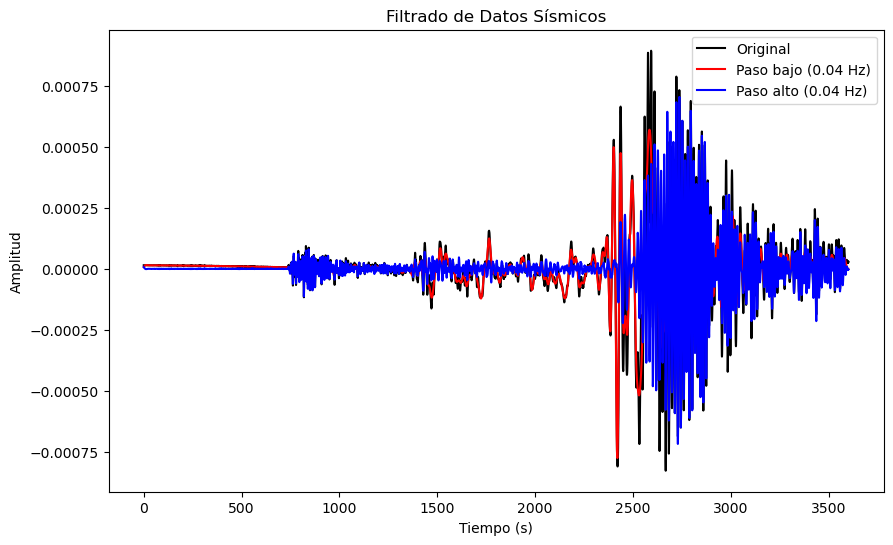

In [16]:
# Graficar resultados
plt.figure(figsize=(10, 6))
plt.plot(st[0].times(), st[0].data, 'k', label='Original')
plt.plot(st_lp[0].times(), st_lp[0].data, 'r', label='Paso bajo (0.04 Hz)')
plt.plot(st_hp[0].times(), st_hp[0].data, 'b', label='Paso alto (0.04 Hz)')
plt.legend()
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Filtrado de Datos Sísmicos')
plt.show();

[Volver al índice](#0-índice)

## 2. Transformada de Fourier y Series de Fourier <a id="2-fourier"></a>
**Transformada de Fourier**

La transformada de Fourier convierte una señal del dominio del tiempo al dominio de la frecuencia. Para una señal continua $f(t)$, la transformada de Fourier es:
$$
F(\omega) = \frac{1}{2\pi} \int_{-\infty}^{\infty} f(t) e^{-i\omega t} \, dt
$$
Para una señal discreta, la transformada discreta de Fourier (DFT) es:
$$
F_k = \frac{1}{N} \sum_{j=0}^{N-1} f_j e^{-2\pi i k j / N}
$$

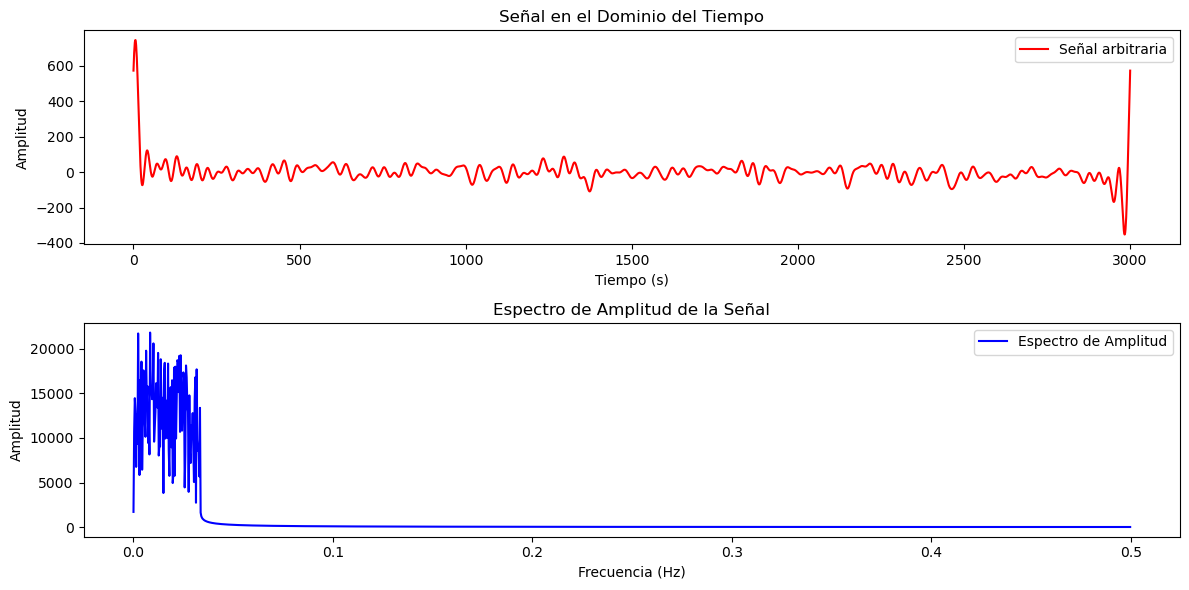

In [17]:
# Parámetros de la señal
samp = 3000  # Número de muestras
dt = 1.0     # Intervalo de muestreo
T = 1.0 / dt # Período
t = np.linspace(0, samp * dt, samp)  # Vector de tiempo

# Crear una señal arbitraria usando coeficientes de Fourier
a0 = np.random.rand(1)  # Coeficiente a0
a = np.random.randint(1, high=11, size=100)  # Coeficientes ak
b = np.random.randint(1, high=11, size=100)  # Coeficientes bk

# Inicializar la señal como un array del mismo tamaño que t
signal = np.ones_like(t) * (a0 / 2)

# Construir la señal usando series de Fourier
for k in range(1, 101):
    signal += a[k-1] * np.cos(2 * np.pi * k * t / T) + b[k-1] * np.sin(2 * np.pi * k * t / T)

# Aplicar la Transformada de Fourier
freqs = fftfreq(samp, dt)
fft_vals = fft(signal)

# Graficar la señal en el dominio del tiempo
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal, 'r', label='Señal arbitraria')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal en el Dominio del Tiempo')
plt.legend()

# Graficar el espectro de amplitud
plt.subplot(2, 1, 2)
plt.plot(freqs[:samp // 2], np.abs(fft_vals[:samp // 2]), 'b', label='Espectro de Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.title('Espectro de Amplitud de la Señal')
plt.legend()

plt.tight_layout()
plt.show()

[Volver al índice](#0-índice)

## 3. Ejercicios <a id="3-ejercicios"></a>

**Filtrado de datos sísmicos:**

    - Elige un evento sísmico de tu interés y descarga los datos utilizand obspy.Client. 
    Puedes seleccionar la red, estación, canal y ventana de tiempo que desees.

    - Detrenda y centra la señal.

    - Aplica filtro paso bajo y paso alto (0.04 Hz).

    - Grafica señal original y filtradas.

### Referencias

Donner, S., Hadziioannou, C. & Nunn, C. (s. f.). Signal Processing: Filtering Basics - Solution. Recuperado de: https://seismo-live.github.io/html/Signal%20Processing/filter_basics_wrapper.html

Donner, S., Hadziioannou, C. & Nunn, C. (s. f.). Signal Processing: Fourier Transformation - Solution. Recuperado de: https://seismo-live.github.io/html/Signal%20Processing/fourier_transform_wrapper.html

Prieta, A. G. (2021). Time Series Analysis and Fourier Methods. Recuperado de: https://github.com/roseseismo/roses2020/blob/main/unit03/time_biglab.ipynb